In [1]:
from LCSS_new import *
import matplotlib.pyplot as plt

c:\Users\bik19\anaconda3\envs\GraphState\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(


1.0 ZXZ_______
1.0 _ZXZ______
1.0 __ZXZ_____
1.0 ___ZXZ____
1.0 ____ZXZ___
1.0 _____ZXZ__
1.0 ______ZXZ_
1.0 _______ZXZ
0.5 Z_________
0.5 _Z________
0.5 __Z_______
0.5 ___Z______
0.5 ____Z_____
0.5 _____Z____
0.5 ______Z___
0.5 _______Z__
0.5 ________Z_
0.5 _________Z
-------------------------------------------
Hamiltonian Expansion
-------------------------------------------
Energy Error: 1.7763568394002505e-15
-------------------------------------------
Stabilizer Error: 0.0
-------------------------------------------
Overlap Error: 9.992007221626409e-16
-------------------------------------------
Energy Matrix Error: 5.329070518200751e-15
-------------------------------------------
LCSS Ground State Error: (-1.5987211554602254e-14+0j)
-------------------------------------------
Restricted Matrix: True
Lowest states: True
-------------------------------------------
DMRG error: 1.7763568394002505e-15


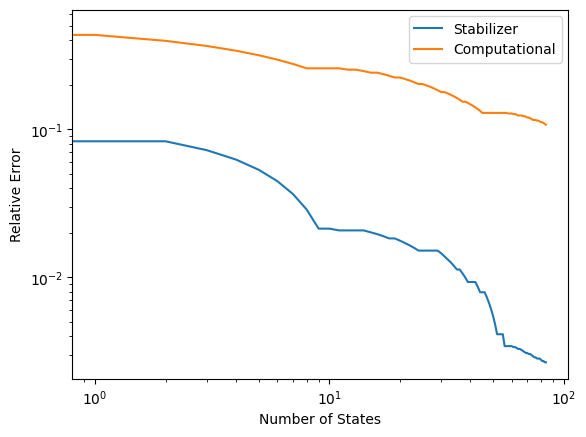

-------------------------------------------
------------extension--------------------
------------overlap--------------------
------------energies--------------------
DMRG error: 2.3092638912203256e-14


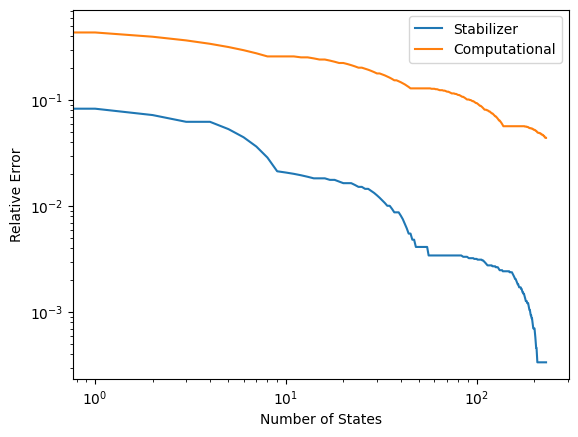

In [2]:
n = 10
g = 0.5

coeffs,paulis = ZXZ_Z_ising_model(n,g)
for c,p in zip(coeffs,paulis):
    print(c,p)

print("-------------------------------------------")
print("Hamiltonian Expansion")
H = Pauli_Hamiltonian(coeffs, paulis)
H_mat = np.einsum('i,ijk',coeffs,[test.pauli_to_mat('+'+p) for p in paulis])
print("-------------------------------------------")
N  = 100
states, energies = H.get_excited_states(N)

### Extend All States ###
extended_states = []
extended_energies = []
for i,s in enumerate(states):
    extended = full_extend_group(s, paulis)
    if extended is not None:
        extended_states.append(extended)
        extended_energies.append(energies[i])
        
### Get the triples ###
triples = [triple.get_triple(s) for s in extended_states]
statevectors = [test.get_state(t) for t in triples]

### Check 1: Energies (good!) ###
d = [] 
for  i,v in enumerate(np.array([s.conjugate().T @ H_mat @ s for s in statevectors])-extended_energies):
    d.append(abs(v))
print(f"Energy Error: {np.max(d)}")
print("-------------------------------------------")
### Check 2: Stabilizers (good!) ###
err = []
for (s,g) in zip(statevectors, extended_states):
    for op in g:
        P = test.pauli_to_mat(op)
        err.append(np.linalg.norm(P @ s - s))
print(f"Stabilizer Error: {np.max(err)}")
print("-------------------------------------------")
### Check 3: Inner Products (good!) ###
N_states = len(extended_states)
O = np.eye(N_states,dtype=complex)
for i in range(0,N_states):
    for j in range(i+1,N_states):
        O[i,j] = triple.inner(triples[i], triples[j])
        O[j,i] = O[i,j].conjugate()
        
O_vec = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        O_vec[i,j] = statevectors[i].conjugate().T @ statevectors[j]

print(f"Overlap Error: {np.max(np.abs(O-O_vec))}")
print("-------------------------------------------")
### Check 4: Energ Matrix (good!) ###
new_states= [[t.apply_pauli(p) for p in paulis] for t in triples]

M = np.array(np.diag(extended_energies),dtype=complex)
for i in range(N_states):
    for j in range(i+1,N_states):
        M[i,j] = np.dot(coeffs,[c*triple.inner(triples[i],t) for (c,t) in (new_states[j])])
        M[j,i] = M[i,j].conjugate() 
        
H_red = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        H_red[i,j] = statevectors[i].conjugate().T @ H_mat @ statevectors[j]
print(f"Energy Matrix Error: {np.max(np.abs(H_red-M))}")
print("-------------------------------------------")
### Check 5: Final LCSS (good!) ###
def solve(O,M):
    O_data = eigh(O)
    valid = [i for i,v in enumerate(O_data[0]) if not np.isclose(v,0)]

    U_plus = O_data[1][:, valid]
    data = eigh(U_plus.conjugate().T @ M @ U_plus, np.diag(O_data[0][valid]))

    E = data[0][0]
    v = U_plus @ data[1][:,0]
    return E,v

E,v = solve(O,M)
final_state = np.sum([c * p for (c,p) in zip(v,statevectors)],axis=0)
print(f"LCSS Ground State Error: {final_state.conjugate().T @ H_mat @ final_state - E}")
print("-------------------------------------------")
N_states = len(extended_states)
classical_states = Z_states(n, N_states)
classical_H = full_matrix(H, classical_states)

H_class = np.zeros((N_states, N_states), dtype=complex)
for i1, s1 in enumerate(classical_states):
    for i2, s2 in enumerate(classical_states):
        H_class[i1,i2]=H_mat[s1, s2]

print(f"Restricted Matrix: {np.allclose(H_class, classical_H)}")
print(f"Lowest states: {np.allclose(np.sort(np.diag(H_mat).real)[:N_states], np.diag(H_class).real)}")
print("-------------------------------------------")
LCSS_data = [solve(O[:i,:i],M[:i,:i])[0].real for i in range(2, N_states)]
classical_data = [np.linalg.eigvalsh(classical_H[:i,:i])[0].real for i in range(2, N_states)]

g = run_dmrg(convert_to_mpos(paulis,coeffs),20)
E = np.linalg.eigvalsh(H_mat)[0]
print(f"DMRG error: {abs(g-E)}")
plt.yscale('log')
plt.xscale('log')

plt.plot((g-np.array(LCSS_data))/g,label='Stabilizer')
plt.plot((g-np.array(classical_data))/g,label='Computational')
plt.xlabel('Number of States')
plt.ylabel('Relative Error')
plt.legend()
plt.show()
print("-------------------------------------------")

instance = LCSS(H)
M,O = instance.run_LCSS(300)
N_states = len(M)

classical_states = Z_states(n, N_states)
classical_H = full_matrix(H, classical_states)

LCSS_data = [solve(O[:i,:i],M[:i,:i])[0].real for i in range(2, N_states)]
classical_data = [np.linalg.eigvalsh(classical_H[:i,:i])[0].real for i in range(2, N_states)]

g = run_dmrg(convert_to_mpos(paulis,coeffs),20)
E = np.linalg.eigvalsh(H_mat)[0]
print(f"DMRG error: {abs(g-E)}")
plt.yscale('log')
plt.xscale('log')

plt.plot((g-np.array(LCSS_data))/g,label='Stabilizer')
plt.plot((g-np.array(classical_data))/g,label='Computational')
plt.xlabel('Number of States')
plt.ylabel('Relative Error')
plt.legend()

1.0 XX________
1.0 _XX_______
1.0 __XX______
1.0 ___XX_____
1.0 ____XX____
1.0 _____XX___
1.0 ______XX__
1.0 _______XX_
1.0 ________XX
0.5 Z_________
0.5 _Z________
0.5 __Z_______
0.5 ___Z______
0.5 ____Z_____
0.5 _____Z____
0.5 ______Z___
0.5 _______Z__
0.5 ________Z_
0.5 _________Z
-------------------------------------------
Hamiltonian Expansion
-------------------------------------------
Energy Error: 1.7763568394002505e-15
-------------------------------------------
Stabilizer Error: 0.0
-------------------------------------------
Overlap Error: 9.992007221626409e-16
-------------------------------------------
Energy Matrix Error: 1.2434497875801753e-14
-------------------------------------------
LCSS Ground State Error: (3.552713678800501e-15+0j)
-------------------------------------------
Restricted Matrix: True
Lowest states: True
-------------------------------------------
DMRG error: 1.0608189882077568e-09


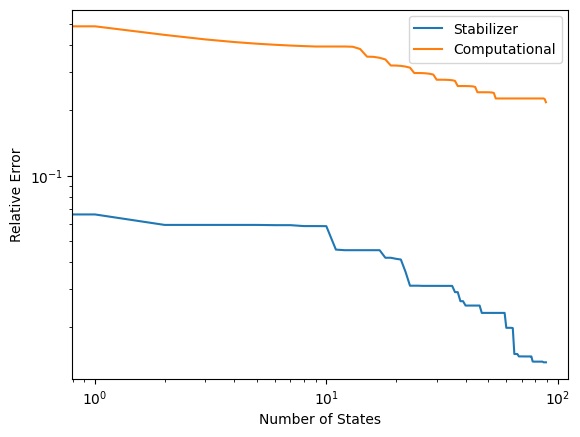

-------------------------------------------
------------extension--------------------
------------overlap--------------------
------------energies--------------------
DMRG error: 6.358789050864289e-10


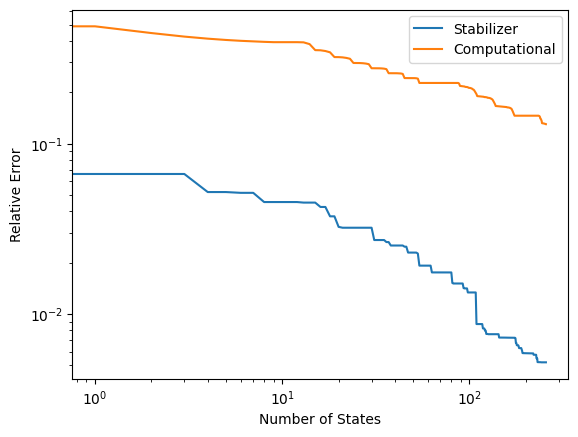

In [3]:
n = 10
g = 0.5

coeffs,paulis = XX_Z_ising_model(n,g)
for c,p in zip(coeffs,paulis):
    print(c,p)

print("-------------------------------------------")
print("Hamiltonian Expansion")
H = Pauli_Hamiltonian(coeffs, paulis)
H_mat = np.einsum('i,ijk',coeffs,[test.pauli_to_mat('+'+p) for p in paulis])
print("-------------------------------------------")
N  = 100
states, energies = H.get_excited_states(N)

### Extend All States ###
extended_states = []
extended_energies = []
for i,s in enumerate(states):
    extended = full_extend_group(s, paulis)
    if extended is not None:
        extended_states.append(extended)
        extended_energies.append(energies[i])
        
### Get the triples ###
triples = [triple.get_triple(s) for s in extended_states]
statevectors = [test.get_state(t) for t in triples]

### Check 1: Energies (good!) ###
d = [] 
for  i,v in enumerate(np.array([s.conjugate().T @ H_mat @ s for s in statevectors])-extended_energies):
    d.append(abs(v))
print(f"Energy Error: {np.max(d)}")
print("-------------------------------------------")
### Check 2: Stabilizers (good!) ###
err = []
for (s,g) in zip(statevectors, extended_states):
    for op in g:
        P = test.pauli_to_mat(op)
        err.append(np.linalg.norm(P @ s - s))
print(f"Stabilizer Error: {np.max(err)}")
print("-------------------------------------------")
### Check 3: Inner Products (good!) ###
N_states = len(extended_states)
O = np.eye(N_states,dtype=complex)
for i in range(0,N_states):
    for j in range(i+1,N_states):
        O[i,j] = triple.inner(triples[i], triples[j])
        O[j,i] = O[i,j].conjugate()
        
O_vec = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        O_vec[i,j] = statevectors[i].conjugate().T @ statevectors[j]

print(f"Overlap Error: {np.max(np.abs(O-O_vec))}")
print("-------------------------------------------")
### Check 4: Energ Matrix (good!) ###
new_states= [[t.apply_pauli(p) for p in paulis] for t in triples]

M = np.array(np.diag(extended_energies),dtype=complex)
for i in range(N_states):
    for j in range(i+1,N_states):
        M[i,j] = np.dot(coeffs,[c*triple.inner(triples[i],t) for (c,t) in (new_states[j])])
        M[j,i] = M[i,j].conjugate() 
        
H_red = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        H_red[i,j] = statevectors[i].conjugate().T @ H_mat @ statevectors[j]
print(f"Energy Matrix Error: {np.max(np.abs(H_red-M))}")
print("-------------------------------------------")
### Check 5: Final LCSS (good!) ###
def solve(O,M):
    O_data = eigh(O)
    valid = [i for i,v in enumerate(O_data[0]) if not np.isclose(v,0)]

    U_plus = O_data[1][:, valid]
    data = eigh(U_plus.conjugate().T @ M @ U_plus, np.diag(O_data[0][valid]))

    E = data[0][0]
    v = U_plus @ data[1][:,0]
    return E,v

E,v = solve(O,M)
final_state = np.sum([c * p for (c,p) in zip(v,statevectors)],axis=0)
print(f"LCSS Ground State Error: {final_state.conjugate().T @ H_mat @ final_state - E}")
print("-------------------------------------------")
N_states = len(extended_states)
classical_states = Z_states(n, N_states)
classical_H = full_matrix(H, classical_states)

H_class = np.zeros((N_states, N_states), dtype=complex)
for i1, s1 in enumerate(classical_states):
    for i2, s2 in enumerate(classical_states):
        H_class[i1,i2]=H_mat[s1, s2]

print(f"Restricted Matrix: {np.allclose(H_class, classical_H)}")
print(f"Lowest states: {np.allclose(np.sort(np.diag(H_mat).real)[:N_states], np.diag(H_class).real)}")
print("-------------------------------------------")
LCSS_data = [solve(O[:i,:i],M[:i,:i])[0].real for i in range(2, N_states)]
classical_data = [np.linalg.eigvalsh(classical_H[:i,:i])[0].real for i in range(2, N_states)]

g = run_dmrg(convert_to_mpos(paulis,coeffs),20)
E = np.linalg.eigvalsh(H_mat)[0]
print(f"DMRG error: {abs(g-E)}")
plt.yscale('log')
plt.xscale('log')

plt.plot((g-np.array(LCSS_data))/g,label='Stabilizer')
plt.plot((g-np.array(classical_data))/g,label='Computational')
plt.xlabel('Number of States')
plt.ylabel('Relative Error')
plt.legend()
plt.show()
print("-------------------------------------------")
instance = LCSS(H)
M,O = instance.run_LCSS(300)
N_states = len(M)

classical_states = Z_states(n, N_states)
classical_H = full_matrix(H, classical_states)

LCSS_data = [solve(O[:i,:i],M[:i,:i])[0].real for i in range(2, N_states)]
classical_data = [np.linalg.eigvalsh(classical_H[:i,:i])[0].real for i in range(2, N_states)]

g = run_dmrg(convert_to_mpos(paulis,coeffs),20)
E = np.linalg.eigvalsh(H_mat)[0]
print(f"DMRG error: {abs(g-E)}")
plt.yscale('log')
plt.xscale('log')

plt.plot((g-np.array(LCSS_data))/g,label='Stabilizer')
plt.plot((g-np.array(classical_data))/g,label='Computational')
plt.xlabel('Number of States')
plt.ylabel('Relative Error')
plt.legend()

1 ZZ________
1 _ZZ_______
1 __ZZ______
1 ___ZZ_____
1 ____ZZ____
1 _____ZZ___
1 ______ZZ__
1 _______ZZ_
1 ________ZZ
1 X_________
1 _X________
1 __X_______
1 ___X______
1 ____X_____
1 _____X____
1 ______X___
1 _______X__
1 ________X_
1 _________X
-------------------------------------------
Hamiltonian Expansion
-------------------------------------------
Energy Error: 1.7763568394002505e-15
-------------------------------------------
Stabilizer Error: 0.0
-------------------------------------------
Overlap Error: 9.992007221626409e-16
-------------------------------------------
Energy Matrix Error: 7.993605777301127e-15
-------------------------------------------
LCSS Ground State Error: (7.105427357601002e-15+0j)
-------------------------------------------
Restricted Matrix: True
Lowest states: True
-------------------------------------------
DMRG error: 3.172278439933507e-09


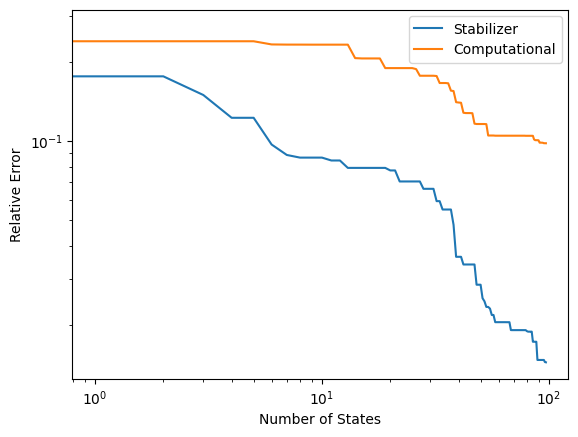

-------------------------------------------
------------extension--------------------
------------overlap--------------------
------------energies--------------------
DMRG error: 3.2905536073712938e-09


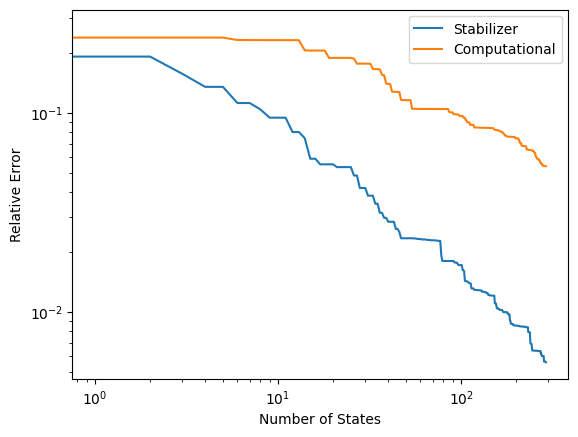

In [4]:
n = 10
g = 1

coeffs,paulis = ZZ_X_ising_model(n,g)
for c,p in zip(coeffs,paulis):
    print(c,p)

print("-------------------------------------------")
print("Hamiltonian Expansion")
H = Pauli_Hamiltonian(coeffs, paulis)
H_mat = np.einsum('i,ijk',coeffs,[test.pauli_to_mat('+'+p) for p in paulis])
print("-------------------------------------------")
N  = 100
states, energies = H.get_excited_states(N)

### Extend All States ###
extended_states = []
extended_energies = []
for i,s in enumerate(states):
    extended = full_extend_group(s, paulis)
    if extended is not None:
        extended_states.append(extended)
        extended_energies.append(energies[i])
        
### Get the triples ###
triples = [triple.get_triple(s) for s in extended_states]
statevectors = [test.get_state(t) for t in triples]

### Check 1: Energies (good!) ###
d = [] 
for  i,v in enumerate(np.array([s.conjugate().T @ H_mat @ s for s in statevectors])-extended_energies):
    d.append(abs(v))
print(f"Energy Error: {np.max(d)}")
print("-------------------------------------------")
### Check 2: Stabilizers (good!) ###
err = []
for (s,g) in zip(statevectors, extended_states):
    for op in g:
        P = test.pauli_to_mat(op)
        err.append(np.linalg.norm(P @ s - s))
print(f"Stabilizer Error: {np.max(err)}")
print("-------------------------------------------")
### Check 3: Inner Products (good!) ###
N_states = len(extended_states)
O = np.eye(N_states,dtype=complex)
for i in range(0,N_states):
    for j in range(i+1,N_states):
        O[i,j] = triple.inner(triples[i], triples[j])
        O[j,i] = O[i,j].conjugate()
        
O_vec = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        O_vec[i,j] = statevectors[i].conjugate().T @ statevectors[j]

print(f"Overlap Error: {np.max(np.abs(O-O_vec))}")
print("-------------------------------------------")
### Check 4: Energ Matrix (good!) ###
new_states= [[t.apply_pauli(p) for p in paulis] for t in triples]

M = np.array(np.diag(extended_energies),dtype=complex)
for i in range(N_states):
    for j in range(i+1,N_states):
        M[i,j] = np.dot(coeffs,[c*triple.inner(triples[i],t) for (c,t) in (new_states[j])])
        M[j,i] = M[i,j].conjugate() 
        
H_red = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        H_red[i,j] = statevectors[i].conjugate().T @ H_mat @ statevectors[j]
print(f"Energy Matrix Error: {np.max(np.abs(H_red-M))}")
print("-------------------------------------------")
### Check 5: Final LCSS (good!) ###
def solve(O,M):
    O_data = eigh(O)
    valid = [i for i,v in enumerate(O_data[0]) if not np.isclose(v,0)]

    U_plus = O_data[1][:, valid]
    data = eigh(U_plus.conjugate().T @ M @ U_plus, np.diag(O_data[0][valid]))

    E = data[0][0]
    v = U_plus @ data[1][:,0]
    return E,v

E,v = solve(O,M)
final_state = np.sum([c * p for (c,p) in zip(v,statevectors)],axis=0)
print(f"LCSS Ground State Error: {final_state.conjugate().T @ H_mat @ final_state - E}")
print("-------------------------------------------")
N_states = len(extended_states)
classical_states = ZZ_states(n, N_states)
classical_H = full_matrix(H, classical_states)

H_class = np.zeros((N_states, N_states), dtype=complex)
for i1, s1 in enumerate(classical_states):
    for i2, s2 in enumerate(classical_states):
        H_class[i1,i2]=H_mat[s1, s2]

print(f"Restricted Matrix: {np.allclose(H_class, classical_H)}")
print(f"Lowest states: {np.allclose(np.sort(np.diag(H_mat).real)[:N_states], np.diag(H_class).real)}")
print("-------------------------------------------")
LCSS_data = [solve(O[:i,:i],M[:i,:i])[0].real for i in range(2, N_states)]
classical_data = [np.linalg.eigvalsh(classical_H[:i,:i])[0].real for i in range(2, N_states)]

g = run_dmrg(convert_to_mpos(paulis,coeffs),20)
E = np.linalg.eigvalsh(H_mat)[0]
print(f"DMRG error: {abs(g-E)}")
plt.yscale('log')
plt.xscale('log')

plt.plot((g-np.array(LCSS_data))/g,label='Stabilizer')
plt.plot((g-np.array(classical_data))/g,label='Computational')
plt.xlabel('Number of States')
plt.ylabel('Relative Error')
plt.legend()
plt.show()
print("-------------------------------------------")
instance = LCSS(H)
M,O = instance.run_LCSS(300)
N_states = len(M)

classical_states = ZZ_states(n, N_states)
classical_H = full_matrix(H, classical_states)

LCSS_data = [solve(O[:i,:i],M[:i,:i])[0].real for i in range(2, N_states)]
classical_data = [np.linalg.eigvalsh(classical_H[:i,:i])[0].real for i in range(2, N_states)]

g = run_dmrg(convert_to_mpos(paulis,coeffs),20)
E = np.linalg.eigvalsh(H_mat)[0]
print(f"DMRG error: {abs(g-E)}")
plt.yscale('log')
plt.xscale('log')

plt.plot((g-np.array(LCSS_data))/g,label='Stabilizer')
plt.plot((g-np.array(classical_data))/g,label='Computational')
plt.xlabel('Number of States')
plt.ylabel('Relative Error')
plt.legend()